In [1]:
%config InlineBackend.figure_format = "svg"

Written by ChatGPT, with minor edits by me, but it illustrates what I want to show (in a surprisingly quantitative way!)

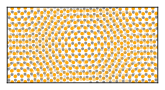

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# MoTe2 lattice constant in nm
a = 0.3472

# Poisson ratio
nu_default = 0.25


def R(phi):
    """2D rotation matrix."""
    return np.array([
        [np.cos(phi), -np.sin(phi)],
        [np.sin(phi),  np.cos(phi)]
    ])


def strain_matrix_realspace(eps, nu=0.25, strain_dir=0.0):
    """
    Real-space uniaxial strain matrix.

    Tensile strain eps along direction d:
        S = I + eps d d^T - nu eps d_perp d_perp^T

    For strain along x:
        x -> (1 + eps) x
        y -> (1 - nu eps) y
    """
    d = np.array([np.cos(strain_dir), np.sin(strain_dir)])
    dp = np.array([np.cos(strain_dir + np.pi/2), np.sin(strain_dir + np.pi/2)])

    return np.eye(2) + eps * np.outer(d, d) - nu * eps * np.outer(dp, dp)


def generate_lattice_points(a=0.3472, Lx=6.0, Ly=6.0, buffer=2.5):
    """
    Generate a large enough triangular lattice so that after rotation/strain
    we can crop to an Lx x Ly region.
    """
    a1 = a * np.array([1.0, 0.0])
    a2 = a * np.array([0.5, np.sqrt(3)/2])

    # Projected in-plane Te offset relative to Mo.
    # The two Te atoms above/below Mo have the same top-view projection here.
    delta_te = (a1 + a2) / 3.0

    Lmax = max(Lx, Ly)
    nmax = int(np.ceil((Lmax + buffer) / a)) + 8

    mo_pts = []
    te_pts = []

    for n1 in range(-nmax, nmax + 1):
        for n2 in range(-nmax, nmax + 1):
            Rcell = n1 * a1 + n2 * a2
            mo_pts.append(Rcell)
            te_pts.append(Rcell + delta_te)

    return np.array(mo_pts), np.array(te_pts)


def crop_rectangle(points, Lx=6.0, Ly=6.0):
    """Crop points to [-Lx/2, Lx/2] x [-Ly/2, Ly/2]."""
    half_x = Lx / 2
    half_y = Ly / 2

    mask = (
        (points[:, 0] >= -half_x) & (points[:, 0] <= half_x) &
        (points[:, 1] >= -half_y) & (points[:, 1] <= half_y)
    )

    return points[mask]


def transform_points(points, theta, eps, nu=0.25, strain_dir=0.0):
    """
    Apply rotation then strain in real space.
    """
    M = strain_matrix_realspace(eps=eps, nu=nu, strain_dir=strain_dir) @ R(theta)
    return points @ M.T


def plot_twisted_bilayer_mote2(
    theta_deg=2.0,
    epsilon=0.01,
    nu=0.25,
    Lx=6.0,
    Ly=6.0,
    strain_dir=0.0,
):
    """
    Plot a real-space top-view scatter plot of twisted bilayer MoTe2.

    Convention:
      bottom layer: rotated by +theta/2, strained with -epsilon
      top layer:    rotated by -theta/2, strained with +epsilon

    For strain along x:
      top layer:
          x -> (1 + epsilon) x
          y -> (1 - nu epsilon) y

      bottom layer:
          x -> (1 - epsilon) x
          y -> (1 + nu epsilon) y
    """
    theta = np.deg2rad(theta_deg)

    # Base lattice
    mo0, te0 = generate_lattice_points(a=a, Lx=Lx, Ly=Ly, buffer=2.5)

    # Bottom layer: +theta/2, -epsilon
    mo_bottom = transform_points(
        mo0, theta=+theta/2, eps=-epsilon, nu=nu, strain_dir=strain_dir
    )
    te_bottom = transform_points(
        te0, theta=+theta/2, eps=-epsilon, nu=nu, strain_dir=strain_dir
    )

    # Top layer: -theta/2, +epsilon
    mo_top = transform_points(
        mo0, theta=-theta/2, eps=+epsilon, nu=nu, strain_dir=strain_dir
    )
    te_top = transform_points(
        te0, theta=-theta/2, eps=+epsilon, nu=nu, strain_dir=strain_dir
    )

    # Crop to final Lx x Ly window
    mo_bottom = crop_rectangle(mo_bottom, Lx=Lx, Ly=Ly)
    te_bottom = crop_rectangle(te_bottom, Lx=Lx, Ly=Ly)
    mo_top = crop_rectangle(mo_top, Lx=Lx, Ly=Ly)
    te_top = crop_rectangle(te_top, Lx=Lx, Ly=Ly)

    # Plot
    fig, ax = plt.subplots(figsize=(2.7, 2.7 * Ly / Lx))

    scatter_kwargs = dict(
        marker="o",
        edgecolors="none",
        linewidths=0,
    )

    # Bottom layer: more opaque
    ax.scatter(
        te_bottom[:, 0], te_bottom[:, 1],
        s=8, c="gray", alpha=0.85, label="Te bottom",
        **scatter_kwargs
    )
    ax.scatter(
        mo_bottom[:, 0], mo_bottom[:, 1],
        s=12, c="orange", alpha=0.95, label="Mo bottom",
        **scatter_kwargs
    )

    # Top layer: more transparent
    ax.scatter(
        te_top[:, 0], te_top[:, 1],
        s=8, c="gray", alpha=0.35, label="Te top",
        **scatter_kwargs
    )
    ax.scatter(
        mo_top[:, 0], mo_top[:, 1],
        s=12, c="orange", alpha=0.45, label="Mo top",
        **scatter_kwargs
    )

    ax.set_xlim(-Lx / 2, Lx / 2)
    ax.set_ylim(-Ly / 2, Ly / 2)
    ax.set_aspect("equal", adjustable="box")

    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.savefig("top-view.pdf", bbox_inches="tight")
    plt.show()


# Example usage
plot_twisted_bilayer_mote2(
    theta_deg=5.0,
    epsilon=0.001,
    nu=0.25,
    Lx=8.0,
    Ly=4.0,
)

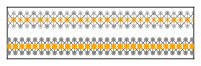

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# In-plane MoTe2 lattice constant in nm
a = 0.3472

# Poisson ratio
nu_default = 0.25

# Out-of-plane geometry in nm
# Approximate monolayer Te-Te vertical thickness
te_te_thickness = 0.359
z_te = te_te_thickness / 2.0

# Approximate Mo-plane to Mo-plane spacing between the two layers
layer_spacing = 0.698


def R(phi):
    """2D rotation matrix."""
    return np.array([
        [np.cos(phi), -np.sin(phi)],
        [np.sin(phi),  np.cos(phi)]
    ])


def strain_matrix_realspace(eps, nu=0.25, strain_dir=0.0):
    """
    Real-space uniaxial strain matrix:
        S = I + eps d d^T - nu eps d_perp d_perp^T

    For strain along x:
        x -> (1 + eps) x
        y -> (1 - nu eps) y
    """
    d = np.array([np.cos(strain_dir), np.sin(strain_dir)])
    dp = np.array([np.cos(strain_dir + np.pi / 2), np.sin(strain_dir + np.pi / 2)])

    return np.eye(2) + eps * np.outer(d, d) - nu * eps * np.outer(dp, dp)


def generate_lattice_points(a=0.3472, Lx=6.0, Ly=1.0, buffer=2.5):
    """
    Generate Mo and projected Te lattice points for a triangular Mo lattice.

    The two Te atoms above and below the Mo plane have the same in-plane
    projection in this simplified top/side-view geometry.
    """
    a1 = a * np.array([1.0, 0.0])
    a2 = a * np.array([0.5, np.sqrt(3) / 2])

    # Projected Te sublattice offset relative to Mo
    delta_te = (a1 + a2) / 3.0

    Lmax = max(Lx, Ly)
    nmax = int(np.ceil((Lmax + buffer) / a)) + 8

    mo_pts = []
    te_pts = []

    for n1 in range(-nmax, nmax + 1):
        for n2 in range(-nmax, nmax + 1):
            r = n1 * a1 + n2 * a2
            mo_pts.append(r)
            te_pts.append(r + delta_te)

    return np.array(mo_pts), np.array(te_pts)


def transform_points(points, theta, eps, nu=0.25, strain_dir=0.0):
    """
    Apply rotation, then real-space strain.
    """
    M = strain_matrix_realspace(eps=eps, nu=nu, strain_dir=strain_dir) @ R(theta)
    return points @ M.T


def crop_strip(points, Lx=6.0, Ly=1.0):
    """
    Crop to a rectangular strip:
        x in [-Lx/2, Lx/2]
        y in [-Ly/2, Ly/2]

    For a side view projected along y, Ly controls the thickness of the
    projected slice.
    """
    mask = (
        (points[:, 0] >= -Lx / 2) & (points[:, 0] <= Lx / 2) &
        (points[:, 1] >= -Ly / 2) & (points[:, 1] <= Ly / 2)
    )

    return points[mask]


def make_bond_segments(mo_xy, te_xy, z_mo, z_te_plane, bond_cutoff):
    """
    Create projected side-view bond segments between Mo atoms and nearby Te atoms.

    Bonds are determined in the transformed in-plane x-y coordinates, then
    projected into the x-z side view.
    """
    segments = []

    for mo in mo_xy:
        dists = np.linalg.norm(te_xy - mo, axis=1)
        neighbor_idx = np.where(dists < bond_cutoff)[0]

        for j in neighbor_idx:
            te = te_xy[j]
            segments.append(((mo[0], z_mo), (te[0], z_te_plane)))

    return segments


def side_view_layer(
    mo0,
    te0,
    theta,
    eps,
    z_mo_center,
    nu=0.25,
    strain_dir=0.0,
    Lx=6.0,
    Ly=1.0,
):
    """
    Build side-view x-z coordinates and bond segments for one MoTe2 monolayer.
    """
    mo_xy = transform_points(
        mo0, theta=theta, eps=eps, nu=nu, strain_dir=strain_dir
    )
    te_xy = transform_points(
        te0, theta=theta, eps=eps, nu=nu, strain_dir=strain_dir
    )

    mo_xy = crop_strip(mo_xy, Lx=Lx, Ly=Ly)
    te_xy = crop_strip(te_xy, Lx=Lx, Ly=Ly)

    # Mo plane
    mo_x = mo_xy[:, 0]
    mo_z = np.full_like(mo_x, z_mo_center)

    # Upper and lower Te planes
    te_x_upper = te_xy[:, 0]
    te_z_upper = np.full_like(te_x_upper, z_mo_center + z_te)

    te_x_lower = te_xy[:, 0]
    te_z_lower = np.full_like(te_x_lower, z_mo_center - z_te)

    # Approximate projected Mo-Te in-plane nearest-neighbor distance
    base_bond_length = a / np.sqrt(3)

    # Slightly enlarge cutoff to tolerate strain/twist
    bond_cutoff = 1.25 * base_bond_length * (1 + abs(eps) + abs(nu * eps))

    bonds_upper = make_bond_segments(
        mo_xy,
        te_xy,
        z_mo=z_mo_center,
        z_te_plane=z_mo_center + z_te,
        bond_cutoff=bond_cutoff,
    )

    bonds_lower = make_bond_segments(
        mo_xy,
        te_xy,
        z_mo=z_mo_center,
        z_te_plane=z_mo_center - z_te,
        bond_cutoff=bond_cutoff,
    )

    return {
        "mo": (mo_x, mo_z),
        "te_upper": (te_x_upper, te_z_upper),
        "te_lower": (te_x_lower, te_z_lower),
        "bonds_upper": bonds_upper,
        "bonds_lower": bonds_lower,
    }


def draw_bonds(ax, segments, lw=0.5, alpha=0.7, zorder=-10):
    """Draw thin black bond lines behind all atoms."""
    for (x1, z1), (x2, z2) in segments:
        ax.plot(
            [x1, x2],
            [z1, z2],
            color="black",
            lw=lw,
            alpha=alpha,
            zorder=zorder,
        )


def plot_side_view_twisted_bilayer_mote2(
    theta_deg=2.0,
    epsilon=0.01,
    nu=0.25,
    Lx=6.0,
    Ly_slice=1.0,
    strain_dir=0.0,
    layer_spacing=0.698,
    bond_lw=0.5,
):
    """
    Side-view x-z projection of twisted, oppositely strained bilayer MoTe2.

    Convention:
      bottom layer: rotated by +theta/2, strained with -epsilon
      top layer:    rotated by -theta/2, strained with +epsilon

    For strain along x:
      top:
          x -> 1 + epsilon
          y -> 1 - nu epsilon

      bottom:
          x -> 1 - epsilon
          y -> 1 + nu epsilon
    """
    theta = np.deg2rad(theta_deg)

    mo0, te0 = generate_lattice_points(
        a=a,
        Lx=Lx,
        Ly=Ly_slice,
        buffer=2.5,
    )

    z_bottom_mo = -layer_spacing / 2
    z_top_mo = +layer_spacing / 2

    bottom = side_view_layer(
        mo0,
        te0,
        theta=+theta / 2,
        eps=-epsilon,
        z_mo_center=z_bottom_mo,
        nu=nu,
        strain_dir=strain_dir,
        Lx=Lx,
        Ly=Ly_slice,
    )

    top = side_view_layer(
        mo0,
        te0,
        theta=-theta / 2,
        eps=+epsilon,
        z_mo_center=z_top_mo,
        nu=nu,
        strain_dir=strain_dir,
        Lx=Lx,
        Ly=Ly_slice,
    )

    fig, ax = plt.subplots(figsize=(3, 1.02))

    # Draw bonds behind all atoms
    draw_bonds(ax, bottom["bonds_upper"], lw=bond_lw, alpha=0.8, zorder=-10)
    draw_bonds(ax, bottom["bonds_lower"], lw=bond_lw, alpha=0.8, zorder=-10)
    draw_bonds(ax, top["bonds_upper"], lw=bond_lw, alpha=0.4, zorder=-10)
    draw_bonds(ax, top["bonds_lower"], lw=bond_lw, alpha=0.4, zorder=-10)

    # Bottom layer atoms
    ax.scatter(
        bottom["te_lower"][0],
        bottom["te_lower"][1],
        s=20,
        c="gray",
        alpha=0.85,
        edgecolors="none",
        label="Te bottom layer",
        zorder=10,
    )
    ax.scatter(
        bottom["te_upper"][0],
        bottom["te_upper"][1],
        s=20,
        c="gray",
        alpha=0.85,
        edgecolors="none",
        zorder=10,
    )
    ax.scatter(
        bottom["mo"][0],
        bottom["mo"][1],
        s=30,
        c="orange",
        alpha=0.95,
        edgecolors="none",
        label="Mo bottom layer",
        zorder=11,
    )

    # Top layer atoms
    ax.scatter(
        top["te_lower"][0],
        top["te_lower"][1],
        s=20,
        c="gray",
        alpha=0.35,
        edgecolors="none",
        label="Te top layer",
        zorder=10,
    )
    ax.scatter(
        top["te_upper"][0],
        top["te_upper"][1],
        s=20,
        c="gray",
        alpha=0.35,
        edgecolors="none",
        zorder=10,
    )
    ax.scatter(
        top["mo"][0],
        top["mo"][1],
        s=30,
        c="orange",
        alpha=0.45,
        edgecolors="none",
        label="Mo top layer",
        zorder=11,
    )

    ax.set_xlim(-Lx / 2, Lx / 2)

    z_min = -layer_spacing / 2 - z_te - 0.15
    z_max = +layer_spacing / 2 + z_te + 0.15
    ax.set_ylim(z_min, z_max)

    ax.set_aspect("equal", adjustable="box")

    plt.xticks([])
    plt.yticks([])
    plt.xlim(-0.49 * Lx, 0.49 * Lx)

    plt.tight_layout()
    plt.savefig("side-view.pdf", bbox_inches="tight")
    plt.show()


# Example usage
plot_side_view_twisted_bilayer_mote2(
    theta_deg=0.0,
    epsilon=0.01,
    nu=0.25,
    Lx=5.0,
    Ly_slice=0.8,
    bond_lw=0.5,
)